## Replaying Checkpoints

- load a checkpoint and replay it back. 

In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph
from pydantic import BaseModel, Field
from typing import TypedDict, Optional
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv()

# -----------------------------
# STATE
# -----------------------------
class GraphState(TypedDict):
    topic: str
    draft: str
    feedback: str
    score: int
    iteration: int
    prev_score: int


# -----------------------------
# LLM
# -----------------------------
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)


# -----------------------------
# STRUCTURED EVALUATION
# -----------------------------
class Evaluation(BaseModel):
    score: int = Field(ge=1, le=10)
    feedback: str = Field(description="Clear bullet-point improvements")


evaluator_llm = llm.with_structured_output(Evaluation)


# -----------------------------
# NODE 1: GENERATE
# -----------------------------
def generate(state: GraphState):
    print(f"\n🧠 Generating (iteration {state.get('iteration', 0)})")

    topic = state.get("topic", "")
    draft = state.get("draft", "")
    feedback = state.get("feedback", "")

    # First draft
    if not draft:
        prompt = f"""
You are a professional business writer.

Write a clear, structured article on:

Topic: {topic}

Requirements:
- Use headings
- Be concise and professional
- Make it suitable for an organizational audience
"""
    else:
        # Improvement loop
        prompt = f"""
You are a senior editor improving content.

Rewrite the article using the feedback below.

Current Draft:
{draft}

Feedback:
{feedback}

Return a significantly improved version.
"""

    response = llm.invoke(prompt).content

    return {
        "draft": response,
        "iteration": state.get("iteration", 0) + 1
    }


# -----------------------------
# NODE 2: EVALUATE
# -----------------------------
def evaluate(state: GraphState):
    print("📊 Evaluating draft...")

    prompt = f"""
You are a strict editorial reviewer.

Evaluate the following content:

Content:
{state['draft']}

Return:
- Score (1–10)
- Bullet-point feedback for improvement
"""

    result = evaluator_llm.invoke(prompt)

    return {
        "score": result.score,
        "feedback": result.feedback
    }


# -----------------------------
# NODE 3: DECISION LOGIC
# -----------------------------
def should_continue(state: GraphState):
    score = state["score"]
    iteration = state["iteration"]
    prev_score = state.get("prev_score", 0)

    print(f"🔁 Score: {score} | Prev: {prev_score} | Iteration: {iteration}")

    # Stop conditions
    if iteration >= 5:
        return "end"

    if score >= 8:
        return "end"

    if score <= prev_score:
        return "end"  # stagnation stop

    return "generate"




In [2]:
# -----------------------------
# GRAPH BUILDING
# -----------------------------
builder = StateGraph(GraphState)

builder.add_node("generate", generate)
builder.add_node("evaluate", evaluate)

builder.add_edge(START, "generate")
builder.add_edge("generate", "evaluate")

builder.add_conditional_edges(
    "evaluate",
    should_continue,
    {
        "generate": "generate",
        "end": END
    }
)

#memory Configuration
checkpointer = MemorySaver()
config = {
    "configurable":{
        "thread_id": "eval01"
    }
}

graph = builder.compile(checkpointer=checkpointer)




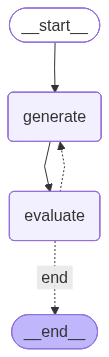

In [5]:
graph

In [6]:
# -----------------------------
# RUN
# -----------------------------
response = graph.invoke({
    "topic": "Leadership Meetings in Modern Organizations",
    "draft": "",
    "feedback": "",
    "score": 0,
    "iteration": 0,
    "prev_score": 0
},
config=config)

# print("\n✅ FINAL OUTPUT:\n")
# print(response["draft"])
# print("\n⭐ Final Score:", response["score"])


🧠 Generating (iteration 0)
📊 Evaluating draft...


c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluation(score=7, feedb...or better readability."), input_type=Evaluation])
  return self.__pydantic_serializer__.to_python(


🔁 Score: 7 | Prev: 0 | Iteration: 1

🧠 Generating (iteration 1)
📊 Evaluating draft...


c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluation(score=7, feedb...he article’s claims.'), input_type=Evaluation])
  return self.__pydantic_serializer__.to_python(


🔁 Score: 7 | Prev: 0 | Iteration: 2

🧠 Generating (iteration 2)
📊 Evaluating draft...
🔁 Score: 8 | Prev: 0 | Iteration: 3


c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluation(score=8, feedb... the original sources.'), input_type=Evaluation])
  return self.__pydantic_serializer__.to_python(


In [7]:
#VISUALIZED THE STATE OF THE GRAPH FROM DIFFERENT SNAPSHOT
#

def print_snapshot_data(snapshot_state):
    thread_id = snapshot_state.config['configurable']['thread_id']
    print("Thread ID:", thread_id)

    checkpoint_id = snapshot_state.config['configurable']['checkpoint_id']
    print("SNAPSHOT ID:", checkpoint_id)


    next_node = snapshot_state.next if snapshot_state.next else "None (Workflow Complete)"
    print("Next Node:", next_node)

    print('-'*50)
    print('State Values:')
    print('-'*50)
    print('Title:', snapshot_state.values.get('topic',''))
    print('Iterations: ', snapshot_state.values.get('iteration',0))
    print('Feedback: ', snapshot_state.values.get('feedback',''))
    print('Draft: ', f'{snapshot_state.values.get('draft','')[100:250]}...')

# get the current state of the graph (this is suppose to be the final state, except you are doing a human in the loop stuff)
print('-'*50)
print('Current Graph State')
print('-'*50)

# get the current state (snapshot)
current_state = graph.get_state(config)

print_snapshot_data(current_state)
###########################################################################################
###########################################################################################

# REPLAY A CHECKPOINT (NODE)
# input [0] -> start node [1]-->generate [2] --> evaluate[3]

#get all checkpoint history as a list
checkpoint_history = list(graph.get_state_history(config))
#get the checkpoint to replay from the checkpoint list (in this instace the 4 index - [3]) - this is evaluate checkpoint
checkpoint_to_replay = checkpoint_history[3]
#get the checkpoint_id for evaluate checkpoint
evaluate_checkpoint_id = checkpoint_to_replay.config["configurable"]["checkpoint_id"]
thread_id = checkpoint_to_replay.config['configurable']['thread_id']

replay_config = {
    "configurable":{
        "thread_id": thread_id,
        "checkpoint_id": evaluate_checkpoint_id
    }
}

print(f"\n Replaying from: {evaluate_checkpoint_id} ...")
print("This will re-evaluate the draft")

replay = graph.invoke(None, replay_config)

print("Replay Complete")
print("DRAFT:\n", replay['draft'])
print("\nFEEDBACK:\n", replay['feedback'])





 

--------------------------------------------------
Current Graph State
--------------------------------------------------
Thread ID: eval01
SNAPSHOT ID: 1f137536-0f03-680a-800e-201988c808db
Next Node: None (Workflow Complete)
--------------------------------------------------
State Values:
--------------------------------------------------
Title: Leadership Meetings in Modern Organizations
Iterations:  3
Feedback:  - **Clarity and Focus**: While the content is generally clear, consider using more concise language in some sections to enhance readability. 
- **Examples**: The provided examples are relevant but could be expanded with more specific data or outcomes to strengthen the points made. 
- **Visual Elements**: Incorporating visual aids (like charts or diagrams) could help illustrate key concepts and improve engagement. 
- **Case Study**: The case study is a strong addition but could benefit from more detailed metrics or qualitative outcomes. 
- **References**: Ensure that the link

c:\lang1\venvi\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluation(score=8, feedb...o bolster credibility.'), input_type=Evaluation])
  return self.__pydantic_serializer__.to_python(
